In [68]:
import numpy as np 
import pandas as pd
import seaborn as sns 

In [69]:
df=pd.read_csv("loan_approval_data.csv")
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [70]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [71]:
# the very first task is to fill these null values which is the part of data cleaning so that proper analysis should be done so with the help of simple imputer we will first fill the different data as per the strategy taken into consoderation as mean and median 

In [72]:
#Handling Missing Values 
categorical_cols=df.select_dtypes(include="object").columns
print(categorical_cols)
numerical_cols=df.select_dtypes(include="float64").columns
print(numerical_cols)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [73]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])


In [74]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [75]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,282.267965,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,262.750000,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000
50%,501.220000,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000
75%,738.250000,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


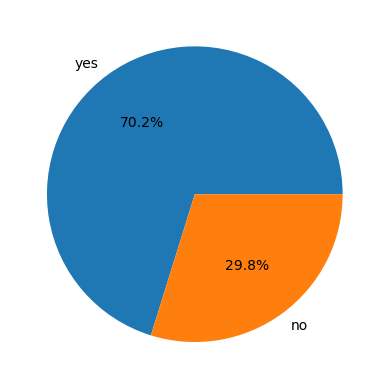

In [76]:
# Exploratory data analysis 
import matplotlib.pyplot as plt
class_count=df["Loan_Approved"].value_counts()
plt.pie(class_count,labels=["yes","no"],autopct="%1.1f%%")
plt.show()

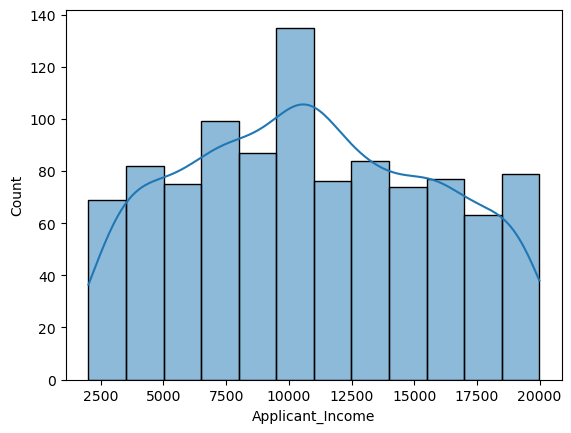

np.float64(0.07438386292973331)

In [77]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.histplot(df["Applicant_Income"],kde=True)
plt.show()
df["Applicant_Income"].skew()

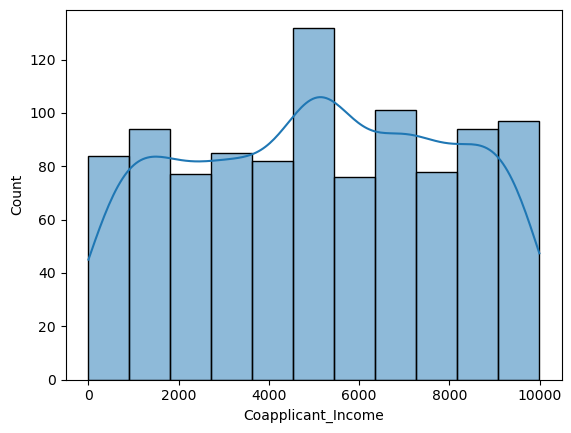

np.float64(-0.05247280470773414)

In [78]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.histplot(df["Coapplicant_Income"],kde=True)
plt.show()
df["Coapplicant_Income"].skew()

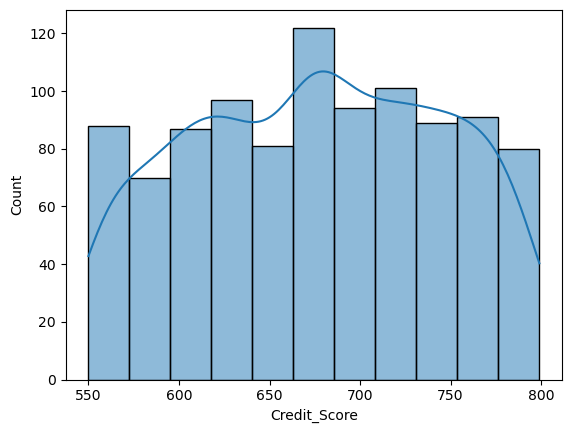

np.float64(-0.06041360558442374)

In [79]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.histplot(df["Credit_Score"],kde=True)
plt.show()
df["Credit_Score"].skew()

In [80]:
#skewness analysis was conducted on key numerical features,specially Applicant_Income,Co_applicant Income, and Credit_Score, as these variables play a crucial role in determining loan eligibility.Income features are often prone to skewness due to the presence of high-income outliers,while Credit Score is a primary financial indicator used by lenders to assess creditworthness. The skewness values for these features were found to be close to zero(0.05),indicating approximately symmetric  distributions.Therefore,no transformation was required.



<Axes: xlabel='Loan_Approved', ylabel='Savings'>

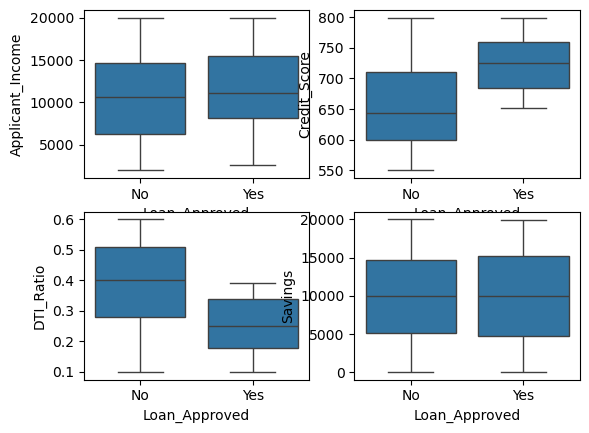

In [81]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

In [ ]:
# Boxplots were created for key numerical features such as Applicant Income ,Credit Score ,DTI Ratio, and Savings to analyze their relationship with target value.Applicant Income suggests repayment ability , Credit Score represents risk profile,DTI score represents debt burdun and savings represents financial backup  

In [83]:
# Creating new feature: Total_Income
df["Total_Income"]=df["Applicant_Income"]+df["Coapplicant_Income"]
df["Loan_to_Income"]=df["Loan_Amount"]/df["Total_Income"]


<Axes: xlabel='Education_Level', ylabel='count'>

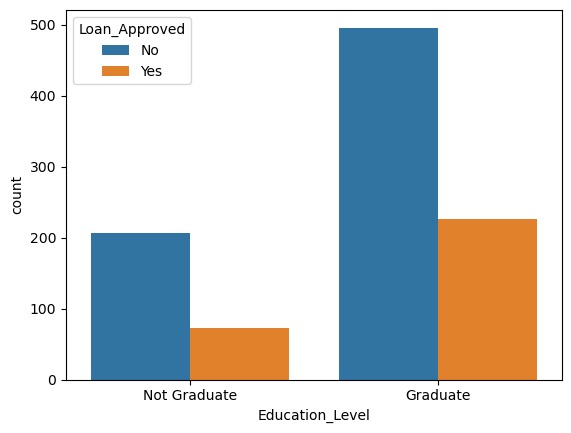

In [84]:

sns.countplot(x="Education_Level",hue="Loan_Approved",data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

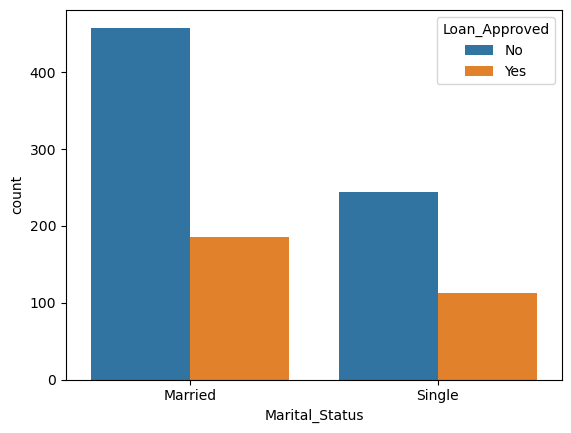

In [85]:
sns.countplot(x="Marital_Status",hue="Loan_Approved",data=df)

<Axes: xlabel='Property_Area', ylabel='count'>

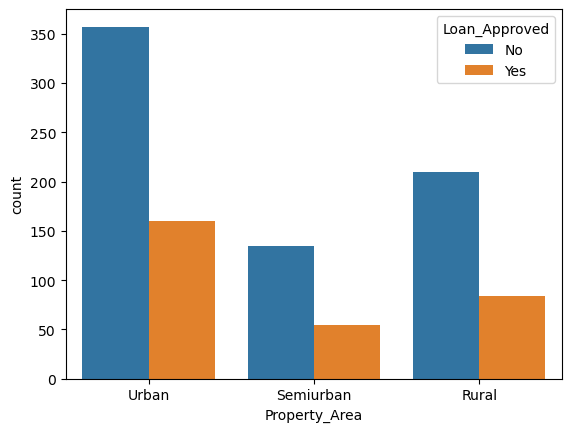

In [86]:
sns.countplot(x="Property_Area",hue="Loan_Approved",data=df)

In [ ]:
# “Categorical feature analysis indicates that property area has a noticeable influence on loan approval decisions, with urban applicants showing higher approval tendencies. In contrast, marital status exhibits only a mild impact, suggesting that financial factors may play a more dominant role than demographic attributes.”

In [87]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [88]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [89]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


<Axes: >

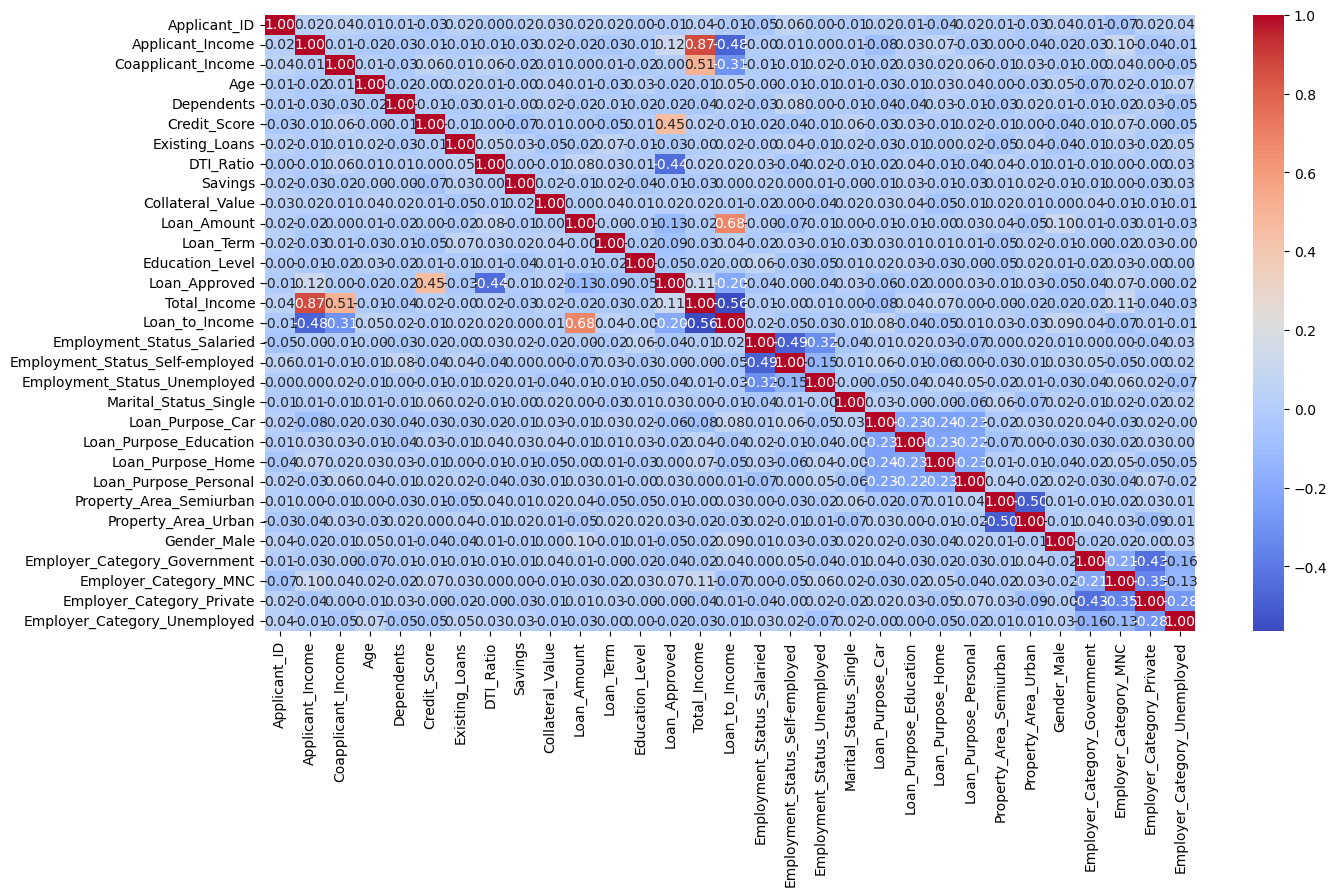

In [90]:
# covariance Heat map for finding linear relation between variables 
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [91]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Total_Income                       0.105343
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried      

In [ ]:
#The correlation matrix was analyzed to understand relationships between features and the target variable (Loan_Approved). 

#It was observed that Credit_Score has the highest positive correlation (0.45), indicating it is a strong predictor. Income-related features also showed moderate correlation, while most other variables had weak relationships.

#This suggests that while some features strongly influence the outcome, others may contribute less and require model-based evaluation.

#The insights from correlation analysis guided feature selection for model training.

In [92]:
# Training model 
from sklearn.model_selection import train_test_split
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

precision 0.78125
recall 0.819672131147541
F1 score 0.8
accuracy 0.875
confusion_matrix [[125  14]
 [ 11  50]]


In [95]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

precision 0.7073170731707317
recall 0.47540983606557374
F1 score 0.5686274509803921
accuracy 0.78
confusion_matrix [[127  12]
 [ 32  29]]


In [96]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7868852459016393
Recall:  0.7868852459016393
F1 score:  0.7868852459016393
Accuracy:  0.87
CM:  [[126  13]
 [ 13  48]]


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

In [ ]:
## 📊 Model Evaluation

#Multiple machine learning models were trained and evaluated to predict loan approval, including Logistic Regression, K-Nearest Neighbors (KNN), and Naive Bayes.

### 🔹 Logistic Regression
#- Accuracy: 87.5%
#- Precision: 0.78
#- Recall: 0.82
#- F1 Score: 0.80

#Logistic Regression performed the best among all models, achieving high accuracy along with a balanced precision-recall trade-off. It effectively identifies both approved and rejected loan applications, making it suitable for real-world deployment.

### 🔹 K-Nearest Neighbors (KNN)
#- Accuracy: 78%
#- Precision: 0.70
#- Recall: 0.47
#- F1 Score: 0.56

#KNN showed lower performance, particularly in recall, indicating that it fails to correctly identify a significant number of approved loan cases.


### 🔹 Naive Bayes
#- Accuracy: 87%
#- Precision: 0.78
#- Recall: 0.78
#- F1 Score: 0.78

#Naive Bayes performed comparably to Logistic Regression but slightly lower in overall balance.

---

## 🏆 Final Model Selection

#Logistic Regression was selected as the final model due to its:
#- High accuracy
#- Balanced performance across precision and recall
#- Better generalization capability


## 💡 Business Interpretation

#In loan approval systems:
#- False Positives (approving risky applicants) can lead to financial losses
#- False Negatives (rejecting good applicants) can lead to lost business opportunities

#The selected model maintains a good balance between these risks, making it reliable for decision-making.